# TUNED MODEL

- Kurangin Neuron
- Adjust Learning Rate

# Import library

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf

import os
import matplotlib.pyplot as plt
import datetime as dt

from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Set Random Seed

In [3]:
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)


# Global variables

In [4]:
EPOCHS = 100
BATCH_SIZE = 8
WINDOW = 5
HORIZON = 1
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.5


# Load data

In [5]:
AAPL = pd.read_csv('./Dataset_A/AAPL.csv', parse_dates=True)

AAPL['Date'] = pd.to_datetime(AAPL['Date'])
AAPL.set_index('Date', inplace=True)

# EDA

In [6]:
AAPL.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


<Axes: xlabel='Date'>

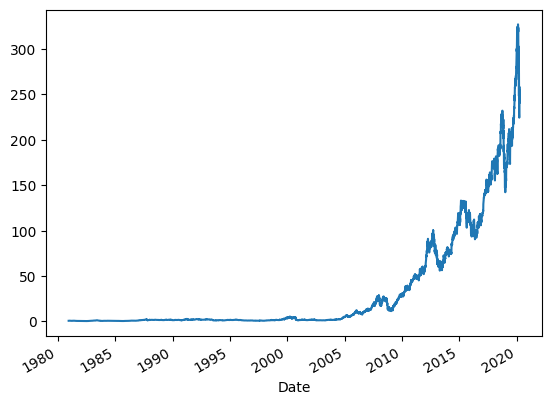

In [7]:
AAPL['Close'].plot()

In [8]:
AAPL['Close'].describe()

count    9909.000000
mean       32.618030
std        58.471899
min         0.196429
25%         1.071429
50%         1.732143
75%        35.761429
max       327.200012
Name: Close, dtype: float64

## Missing Values

In [9]:
AAPL.isna().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

# Preprocessing

## Drop Unnecessary Columns

In [10]:
AAPL_close = AAPL.copy()[['Close']]
AAPL_close.head()

,Close
Date,
1980-12-12,0.513393
1980-12-15,0.486607
1980-12-16,0.450893
1980-12-17,0.462054
1980-12-18,0.475446


## Data Normalization

In [11]:
data = AAPL_close.values.tolist()

class MinMaxScaling:
    def __init__(self, data):
        self.data = np.array(data, dtype='float32')
        self.min = self.data.min(axis=0)
        self.max = self.data.max(axis=0)
    
    def __call__(self):
        return list((self.data - self.min)/(self.max - self.min))
    
    def inverse(self, data):
        return list(data*(self.max - self.min) + self.min)

min_max_scaler = MinMaxScaling(data)

In [12]:
data = min_max_scaler()

## Create TimeSeries Instances

In [13]:
def create_instances(data, window : int = 1, future : int = 1):
    X, y = [], []
    for i in range(len(data)-window-future):
        feature = data[i : i+window]
        # target = data[i+future+1 : i+window+future+1]
        target = data[i+window+future]
        X.append(feature)
        y.append(target)
    return X, y

In [14]:
X, y = create_instances(data, window=WINDOW, future=HORIZON)

## Split Data (Train, Validation, Test)

In [15]:
# Split the data with 80% for training and 10% for validation and 10% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SPLIT, shuffle=False, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, train_size=VAL_SPLIT, shuffle=False, random_state=42)

## Convert Data to Tensor Slices

In [16]:
# Convert the data to tensors and create dataloaders

X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

X_val = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float32)

X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

train_data = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE)
val_data = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_data = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

# Base Model (LSTM)

## Define Model Architecture

In [18]:
input_layer = Input(shape=(WINDOW, 1))
lstm_layer = LSTM(25, activation='relu')(input_layer)
output_layer = Dense(1)(lstm_layer)
tuned_model = Model(input_layer, output_layer)

In [19]:
tuned_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 5, 1)]            0         
                                                                 
 lstm_1 (LSTM)               (None, 25)                2700      
                                                                 
 dense_1 (Dense)             (None, 1)                 26        
                                                                 
Total params: 2,726
Trainable params: 2,726
Non-trainable params: 0
_________________________________________________________________


## Compile Model

In [20]:
tuned_model.compile(optimizer=Adam(learning_rate=0.0001), loss='mae', metrics=[RootMeanSquaredError(), 'mae', 'mape'])

## Train Model

In [21]:
checkpointer = ModelCheckpoint(filepath = './exp/AAPL/weights_best.hdf5', verbose = 1, save_best_only = True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

his_baseModel=tuned_model.fit(train_data, 
               epochs=EPOCHS, 
               validation_data=val_data, 
               batch_size=BATCH_SIZE, 
               callbacks=[checkpointer, early_stopping])

Epoch 1/100
991/991 [==============================] - ETA: 0s - loss: 0.0024 - root_mean_squared_error: 0.0051 - mae: 0.0024 - mape: 40.7123
Epoch 1: val_loss improved from inf to 0.02568, saving model to ./exp/AAPL\weights_best.hdf5
991/991 [==============================] - 17s 15ms/step - loss: 0.0024 - root_mean_squared_error: 0.0051 - mae: 0.0024 - mape: 40.7123 - val_loss: 0.0257 - val_root_mean_squared_error: 0.0321 - val_mae: 0.0257 - val_mape: 8.1265
Epoch 2/100
990/991 [============================>.] - ETA: 0s - loss: 0.0063 - root_mean_squared_error: 0.0168 - mae: 0.0063 - mape: 7473.1919
Epoch 2: val_loss improved from 0.02568 to 0.00956, saving model to ./exp/AAPL\weights_best.hdf5
991/991 [==============================] - 15s 15ms/step - loss: 0.0063 - root_mean_squared_error: 0.0168 - mae: 0.0063 - mape: 7471.3062 - val_loss: 0.0096 - val_root_mean_squared_error: 0.0119 - val_mae: 0.0096 - val_mape: 3.3915
Epoch 3/100
987/991 [============================>.] - ETA: 0s

## Evaluate Model

In [22]:
print('Best Validation Loss (MAE): ', min_max_scaler.inverse(min(his_baseModel.history['val_loss'])))
print('Best Training Loss (MAE): ', min_max_scaler.inverse(min(his_baseModel.history['loss'])))
print('Best MAPE: ',min(his_baseModel.history['val_mape']))

Best Validation Loss (MAE):  [2.4931202]
Best Training Loss (MAE):  [0.53296566]
Best MAPE:  2.6659374237060547


Terdapat rata-rata deviasi absolut sebesar 2 dan MAPE sebesar 2% pada set validasi. Hal ini dapat diartikan bahwa model prediksi harga saham memiliki rata-rata deviasi sebesar 2% atau 2 dollar. Hasil yang sangat baik yang berarti model berhasil improve secara major

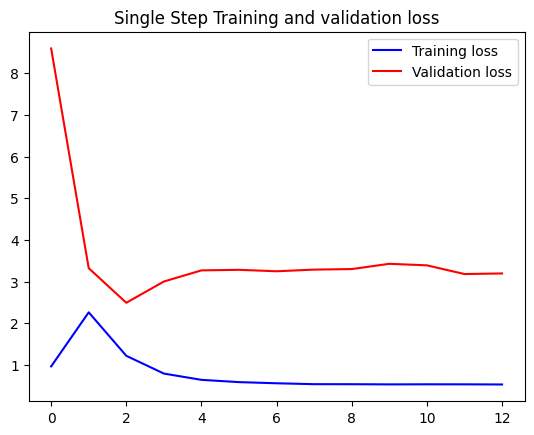

In [23]:
def plot_train_history(history, title):
    loss = min_max_scaler.inverse(history.history['loss'])
    val_loss = min_max_scaler.inverse(history.history['val_loss'])

    epochs = range(len(loss))

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.legend()

    plt.show()
    
plot_train_history(his_baseModel, 'Single Step Training and validation loss')

Model sudah tidak terlalu overfitting dan sudah cukup baik dalam memprediksi harga saham

## Model Inference 

### Test Data Prediction & Evaluation

In [25]:
# Load best weights
tuned_model.load_weights('./exp/AAPL/weights_best.hdf5')

# Evaluate the model
results = tuned_model.evaluate(test_data)

print('Test Loss (MAE): ', min_max_scaler.inverse(results[0]))
print('Test RMSE: ', min_max_scaler.inverse(results[1]))
print('Test MAPE: ', results[3])

124/124 [==============================] - 1s 6ms/step - loss: 0.0267 - root_mean_squared_error: 0.0471 - mae: 0.0267 - mape: 4.0777
Test Loss (MAE):  [8.93179]
Test RMSE:  [15.603119]
Test MAPE:  4.0777201652526855


Hasil MAE dan Mape sudah baik dalam test data dengan deviasi rata rata 8$ dan MAPE 4%

In [26]:
# Predict the future stock price
predictions = tuned_model.predict(test_data)

124/124 [==============================] - 1s 3ms/step


### Visualization

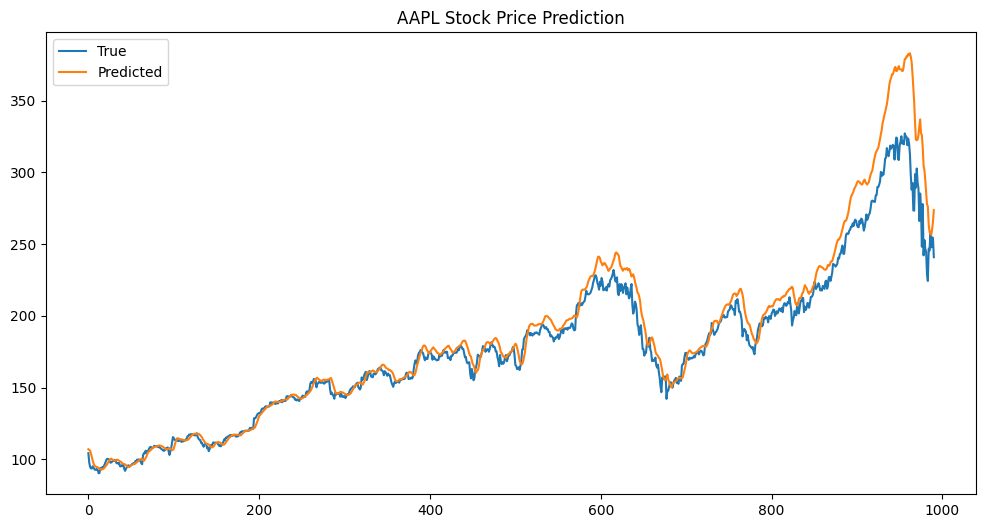

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(min_max_scaler.inverse(y_test), label='True')
plt.plot(min_max_scaler.inverse(predictions), label='Predicted')
plt.title('AAPL Stock Price Prediction')
plt.legend()
plt.show()

Secara visual Model dapat memprediksi harga saham dengan baik pada awal tetapi mulai over predict pada akhir